# MIMII Sound Anomaly Detection — Exploratory Data Analysis

**Dataset:** MIMII (Malfunctioning Industrial Machine Investigation and Inspection)  
**Machine type:** Fan (−6 dB SNR split)  
**Task:** Unsupervised / semi-supervised anomaly detection — models are trained **only on normal sounds** and must flag anomalous ones at inference time.

## Dataset layout

```
fan/
  id_00/
    normal/      ← training pool (only these are used to fit models)
    abnormal/    ← test set (labels withheld at train time)
  id_02/ ...
  id_04/ ...
  id_06/ ...
```

Each file is a **10-second, 16 kHz, 8-channel** recording from a circular microphone array. The −6 dB split is the hardest: significant background noise is mixed in, simulating a realistic factory floor.

In [1]:
#Using Colab?
COLAB = False

In [2]:
# ── imports ──────────────────────────────────────────────────────────────────
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Audio, display

# ── global style ─────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── paths ─────────────────────────────────────────────────────────────────────
if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')  
    DATA_ROOT = Path('drive/MyDrive/ASD-with-SSL/data/fan') 
else:
    DATA_ROOT = Path('fan')
MACHINE_IDS = ['id_00', 'id_02', 'id_04', 'id_06']
SR = 16_000               # native sample rate
CHANNEL = 0               # which mic channel to use (0–7); channel 0 is conventional

## 1 — Dataset inventory

Before touching audio, we count files and build a manifest DataFrame.  
This is the ground truth reference for every downstream split.

In [3]:
from sklearn.model_selection import train_test_split

records = []
for machine_id in MACHINE_IDS:
    for label in ('normal', 'abnormal'):
        for wav in sorted((DATA_ROOT / machine_id / label).glob('*.wav')):
            records.append({'machine_id': machine_id, 'label': label, 'path': wav})

manifest = pd.DataFrame(records)
manifest['is_anomaly'] = (manifest['label'] == 'abnormal').astype(int)
manifest['split'] = None

# ── SSL-aware split (per machine ID to keep proportions balanced) ─────────────
# Normal  : 70% pretrain | 10% finetune | 20% val
# Abnormal: 20% finetune | 80% val
#
# Leakage rules enforced by construction:
#   • The SSL feature extractor only ever sees  normal_pretrain
#   • Fine-tuning only ever sees  normal_finetune + abnormal_finetune
#   • Evaluation only ever sees   normal_val     + abnormal_val
#   • Normalisation stats are computed from normal_pretrain only
for machine_id in MACHINE_IDS:
    # abnormal ────────────────────────────────────────────────────────────────
    abn = manifest[
        (manifest['machine_id'] == machine_id) & (manifest['label'] == 'abnormal')
    ].index
    abn_ft, abn_val = train_test_split(abn, test_size=0.80, random_state=SEED)
    manifest.loc[abn_ft,  'split'] = 'abnormal_finetune'
    manifest.loc[abn_val, 'split'] = 'abnormal_val'

    # normal ──────────────────────────────────────────────────────────────────
    norm = manifest[
        (manifest['machine_id'] == machine_id) & (manifest['label'] == 'normal')
    ].index
    norm_pre, norm_rest = train_test_split(norm, test_size=0.30, random_state=SEED)
    # Of the 30% held back: 1/3 → finetune (≈10% total), 2/3 → val (≈20% total)
    norm_ft, norm_val   = train_test_split(norm_rest, test_size=2/3, random_state=SEED)
    manifest.loc[norm_pre, 'split'] = 'normal_pretrain'
    manifest.loc[norm_ft,  'split'] = 'normal_finetune'
    manifest.loc[norm_val, 'split'] = 'normal_val'

print(f'Total files: {len(manifest):,}')
print()
manifest.groupby(['machine_id', 'split']).size().unstack(fill_value=0)[
    ['normal_pretrain', 'normal_finetune', 'normal_val',
     'abnormal_finetune', 'abnormal_val']
]

Total files: 5,550



split,normal_pretrain,normal_finetune,normal_val,abnormal_finetune,abnormal_val
machine_id,,,,,
id_00,707,101,203,81,326
id_02,711,101,204,71,288
id_04,723,103,207,69,279
id_06,710,101,204,72,289


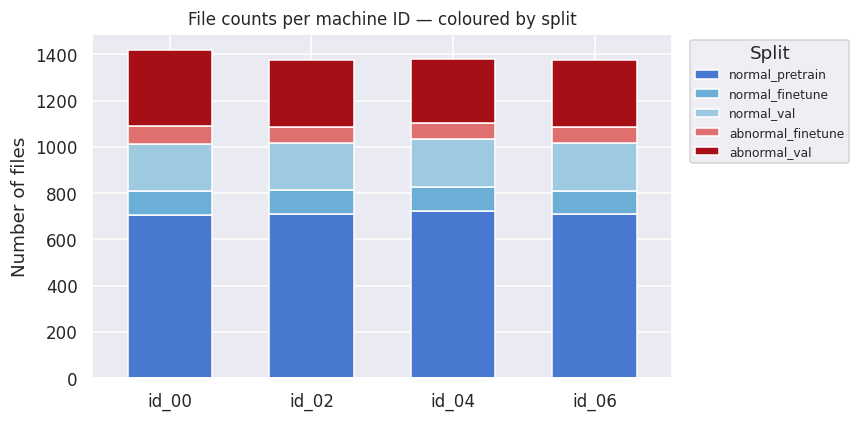

In [4]:
# ── stacked bar: file counts per split and machine ID ────────────────────────
split_order  = ['normal_pretrain', 'normal_finetune', 'normal_val',
                 'abnormal_finetune', 'abnormal_val']
split_colors = ['#4878cf', '#6baed6', '#9ecae1', '#e07070', '#a50f15']

counts = manifest.groupby(['machine_id', 'split']).size().unstack(fill_value=0)[split_order]

ax = counts.plot(kind='bar', stacked=True, figsize=(8, 4),
                  color=split_colors, edgecolor='white', width=0.6)
ax.set_title('File counts per machine ID — coloured by split')
ax.set_xlabel('')
ax.set_ylabel('Number of files')
ax.legend(title='Split', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Normal samples outnumber abnormal roughly 3:1 across all IDs — a deliberate design choice reflecting real deployment conditions where faults are rare.  
This imbalance means **accuracy is a misleading metric**; we will use AUC-ROC throughout.

## 1.1 — SSL pipeline data split

Our training pipeline has three distinct stages, each requiring its own data pool:

| Stage | Data used | Purpose |
|---|---|---|
| **SSL pre-training** | `normal_pretrain` only | Learn a feature extractor from normal sounds; no labels used |
| **Fine-tuning** | `normal_finetune` + `abnormal_finetune` | Adapt the feature map using a small number of labelled examples |
| **Evaluation** | `normal_val` + `abnormal_val` | Measure AUC-ROC on held-out data the model has never touched |

### Split ratios

```
Normal files (~1011 per ID)
  ├── normal_pretrain   70%  ≈ 707   ← SSL feature extractor
  ├── normal_finetune   10%  ≈ 101   ← fine-tuning (paired with abnormal_finetune)
  └── normal_val        20%  ≈ 203   ← evaluation

Abnormal files (~380 per ID)
  ├── abnormal_finetune 20%  ≈  76   ← fine-tuning (the 'small subset')
  └── abnormal_val      80%  ≈ 304   ← evaluation
```


In [5]:
# ── sanity-check: verify no file appears in more than one split ──────────────
assert manifest['split'].isna().sum() == 0, 'Some files have no split assigned!'
assert manifest.groupby('path')['split'].nunique().max() == 1, 'A file appears in multiple splits!'
print('Split assignment verified — no leakage by construction.')
print()

# ── per-ID summary table ──────────────────────────────────────────────────────
split_order = ['normal_pretrain', 'normal_finetune', 'normal_val',
                'abnormal_finetune', 'abnormal_val']
summary = manifest.groupby(['machine_id', 'split']).size().unstack(fill_value=0)[split_order]
summary['total'] = summary.sum(axis=1)
summary

Split assignment verified — no leakage by construction.



split,normal_pretrain,normal_finetune,normal_val,abnormal_finetune,abnormal_val,total
machine_id,,,,,,
id_00,707,101,203,81,326,1418
id_02,711,101,204,71,288,1375
id_04,723,103,207,69,279,1381
id_06,710,101,204,72,289,1376


## 2 — Loading audio & channel strategy

Each file holds **8 channels** recorded simultaneously by a circular mic array.  
The MIMII authors do not specify a canonical channel for downstream tasks.  
Three common strategies:

| Strategy | Code | Notes |
|---|---|---|
| Single channel | `audio[:, 0]` | Fast; loses spatial info |
| Mono mix | `audio.mean(axis=1)` | Averages out directional noise |
| Multi-channel | keep all | More information; higher compute cost |

We start with **channel 0** (simplest), verify there is no silent or pathological channel, then revisit.

In [6]:
def load_mono(path, channel=CHANNEL, sr=SR):
    """Load a single channel from a MIMII WAV file. Returns 1-D float32 array."""
    audio, file_sr = sf.read(path, dtype='float32')
    assert file_sr == sr, f"Unexpected sample rate {file_sr} in {path}"
    return audio[:, channel] if audio.ndim == 2 else audio

# Quick sanity check on one file per ID/class
for row in manifest.groupby(['machine_id', 'label']).first().itertuples():
    y = load_mono(row.path)
    print(f"{row.Index} | shape: {y.shape} | duration: {len(y)/SR:.1f}s "
          f"| RMS: {np.sqrt(np.mean(y**2)):.4f} | max: {np.abs(y).max():.4f}")

('id_00', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0134 | max: 0.0555
('id_00', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0107 | max: 0.0518
('id_02', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0107 | max: 0.0474
('id_02', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0113 | max: 0.0490
('id_04', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0118 | max: 0.0532
('id_04', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0110 | max: 0.0474
('id_06', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0102 | max: 0.0450
('id_06', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0114 | max: 0.0484


### 2.1 — Channel energy comparison

We check whether any channel is systematically quieter (broken mic) across a sample of files.

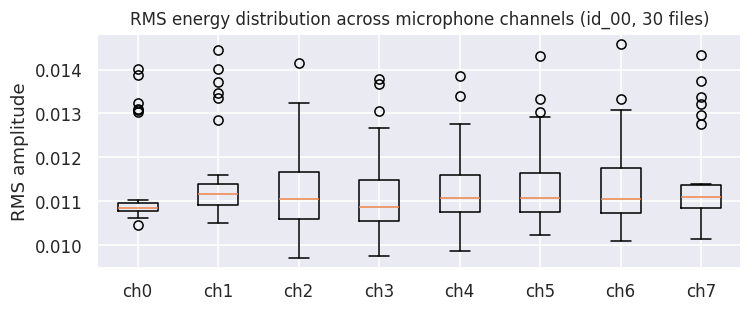

In [7]:
sample_paths = manifest[manifest['machine_id'] == 'id_00']['path'].sample(30, random_state=SEED).tolist()

rms_per_channel = np.zeros((len(sample_paths), 8))
for i, p in enumerate(sample_paths):
    audio, _ = sf.read(p, dtype='float32')
    rms_per_channel[i] = np.sqrt(np.mean(audio**2, axis=0))

fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot(rms_per_channel, tick_labels=[f'ch{i}' for i in range(8)])
ax.set_title('RMS energy distribution across microphone channels (id_00, 30 files)')
ax.set_ylabel('RMS amplitude')
plt.tight_layout()
plt.show()

Most channels seem to have the same average RMS energy amplitude meaning we could use a single channel for our analysis. The spread of the RMS doesn't appear to be the same, a high variance channel might contain some extra information.

In [8]:
top_spread_ch = rms_per_channel.std(axis=0).argmax()
print(f"Channel with highest RMS spread: ch{top_spread_ch} (RMS std: {rms_per_channel[:, top_spread_ch].std():.6f})")

Channel with highest RMS spread: ch1 (RMS std: 0.001097)


## 3 — Listening to the data

In [9]:
for machine_id in ['id_00']:          # expand to other IDs as desired
    for label in ('normal', 'abnormal'):
        path = manifest[(manifest['machine_id'] == machine_id) &
                        (manifest['label'] == label)]['path'].iloc[0]
        y = load_mono(path)
        print(f"▶  {machine_id} / {label}")
        display(Audio(y, rate=SR))

▶  id_00 / normal


▶  id_00 / abnormal


## 4 — Waveform visualization

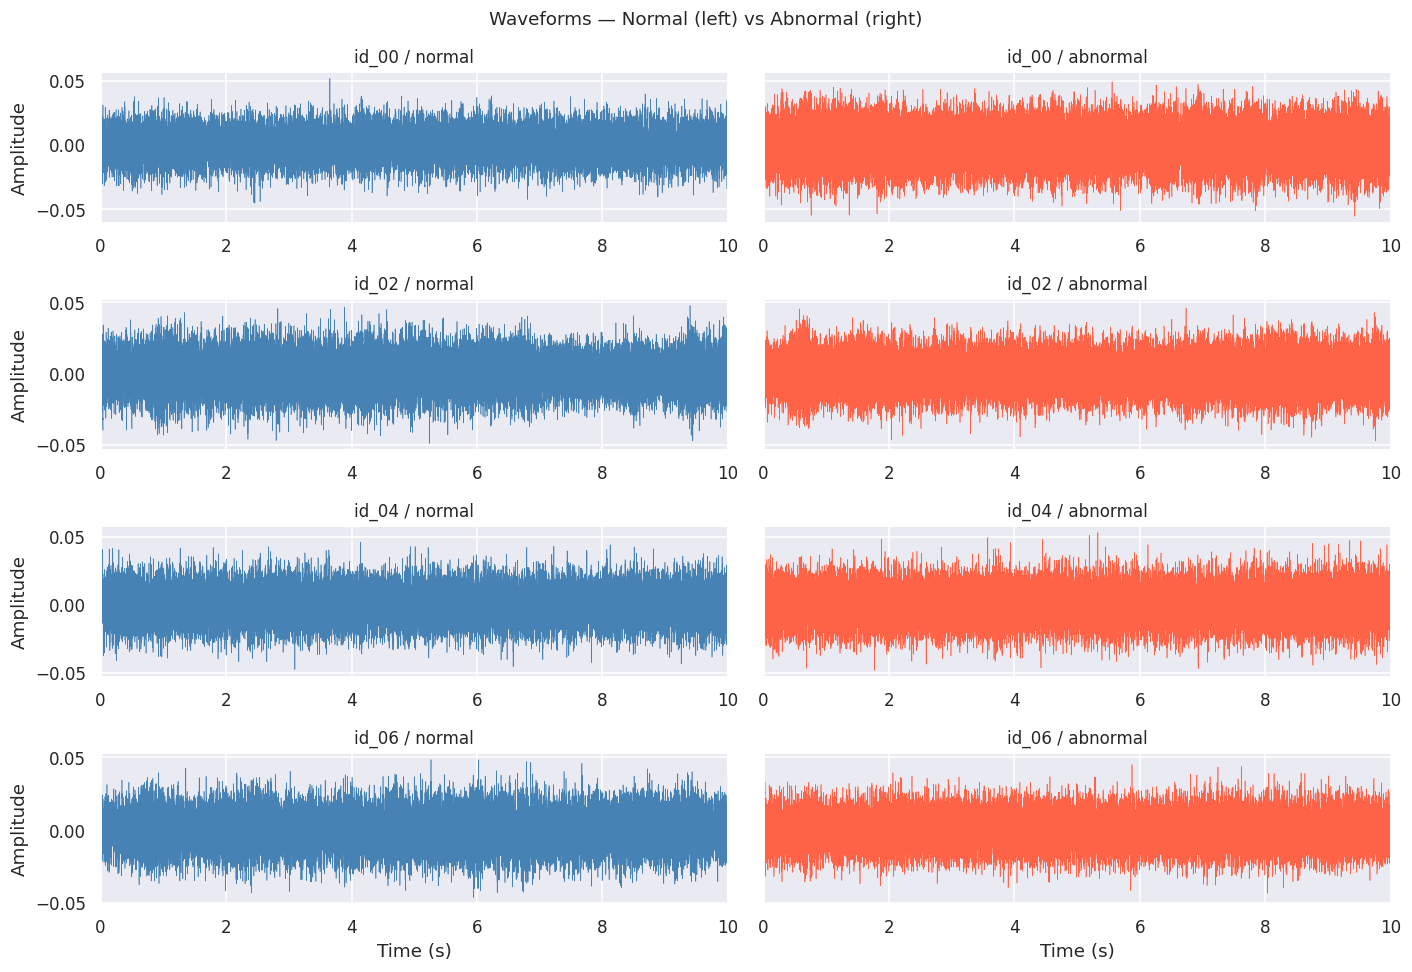

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(13, 9), sharey='row')
fig.suptitle('Waveforms — Normal (left) vs Abnormal (right)', fontsize=12)

t = np.linspace(0, 10, SR * 10)

for row_idx, machine_id in enumerate(MACHINE_IDS):
    for col_idx, label in enumerate(('normal', 'abnormal')):
        path = manifest[(manifest['machine_id'] == machine_id) &
                        (manifest['label'] == label)]['path'].iloc[0]
        y = load_mono(path)
        ax = axes[row_idx, col_idx]
        ax.plot(t, y, linewidth=0.4, color='steelblue' if label == 'normal' else 'tomato')
        ax.set_title(f'{machine_id} / {label}')
        ax.set_xlim(0, 10)
        if col_idx == 0:
            ax.set_ylabel('Amplitude')
        if row_idx == 3:
            ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

No major differences can be directly observed from these.

## 5 — Spectral analysis

The waveform alone rarely reveals anomalies — they often appear as shifts in specific frequency bands.  
We will look at three representations:

1. **Short-Time Fourier Transform (STFT)** spectrogram — raw frequency content vs. time  
2. **Log-mel spectrogram** — perceptually scaled, the standard input for deep learning models  
3. **MFCC** — compact spectral envelope, useful for classical ML baselines

In [11]:
# ── feature extraction helpers ────────────────────────────────────────────────
N_FFT   = 1024   # FFT window size → frequency resolution
HOP_LEN = 512    # hop size → time resolution
N_MELS  = 64     # mel filter bank size
N_MFCC  = 40     # number of MFCC coefficients

# Number of time frames produced from a 10-second clip:
#   T = 1 + (N_samples // HOP_LEN) = 1 + (160 000 // 512) = 313

def compute_log_mel(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN, n_mels=N_MELS):
    """
    Inputs
    ------
    y          : np.ndarray, shape (N,), dtype float32
                 Mono audio waveform.  N = sr * duration.
                 For a 10-second MIMII clip: N = 160 000.
    sr         : int  — sample rate in Hz (default 16 000)
    n_fft      : int  — FFT window length in samples (default 1 024)
                 Controls frequency resolution: n_fft // 2 + 1 unique bins.
    hop_length : int  — step size between successive FFT windows (default 512)
                 Controls time resolution: smaller → more frames, more compute.
    n_mels     : int  — number of mel filterbank channels (default 64)

    Output
    ------
    np.ndarray, shape (n_mels, T), dtype float32
        Log-power mel spectrogram in decibels, normalised so the loudest
        frame is 0 dB.  Typical range: [-80, 0] dB.
        T = 1 + N // hop_length  →  313 for a 10-second MIMII clip.
        Rows index mel frequency bands (low → high).
        Columns index time frames.
    """
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,
                                        hop_length=hop_length, n_mels=n_mels)
    return librosa.power_to_db(S, ref=np.max)


def compute_mfcc(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN,
                  n_mels=N_MELS, n_mfcc=N_MFCC):
    """
    Inputs
    ------
    y          : np.ndarray, shape (N,), dtype float32
                 Same mono waveform as compute_log_mel.
    sr         : int  — sample rate in Hz (default 16 000)
    n_fft      : int  — FFT window length in samples (default 1 024)
    hop_length : int  — step size between windows (default 512)
    n_mels     : int  — mel filterbank channels used internally (default 64)
                 The log-mel spectrogram is an intermediate step; MFCCs are
                 the DCT of the log-mel energies.
    n_mfcc     : int  — number of cepstral coefficients to return (default 40)

    Output
    ------
    np.ndarray, shape (n_mfcc, T), dtype float32
        Matrix of MFCC coefficients.  Typical range: roughly [-300, 100].
        T = 1 + N // hop_length  →  313 for a 10-second MIMII clip.
        Row 0 (MFCC-0) encodes overall log-energy; rows 1–39 encode the
        spectral envelope shape from coarse to fine.
        Columns index time frames (same grid as compute_log_mel).
    """
    return librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                  n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)


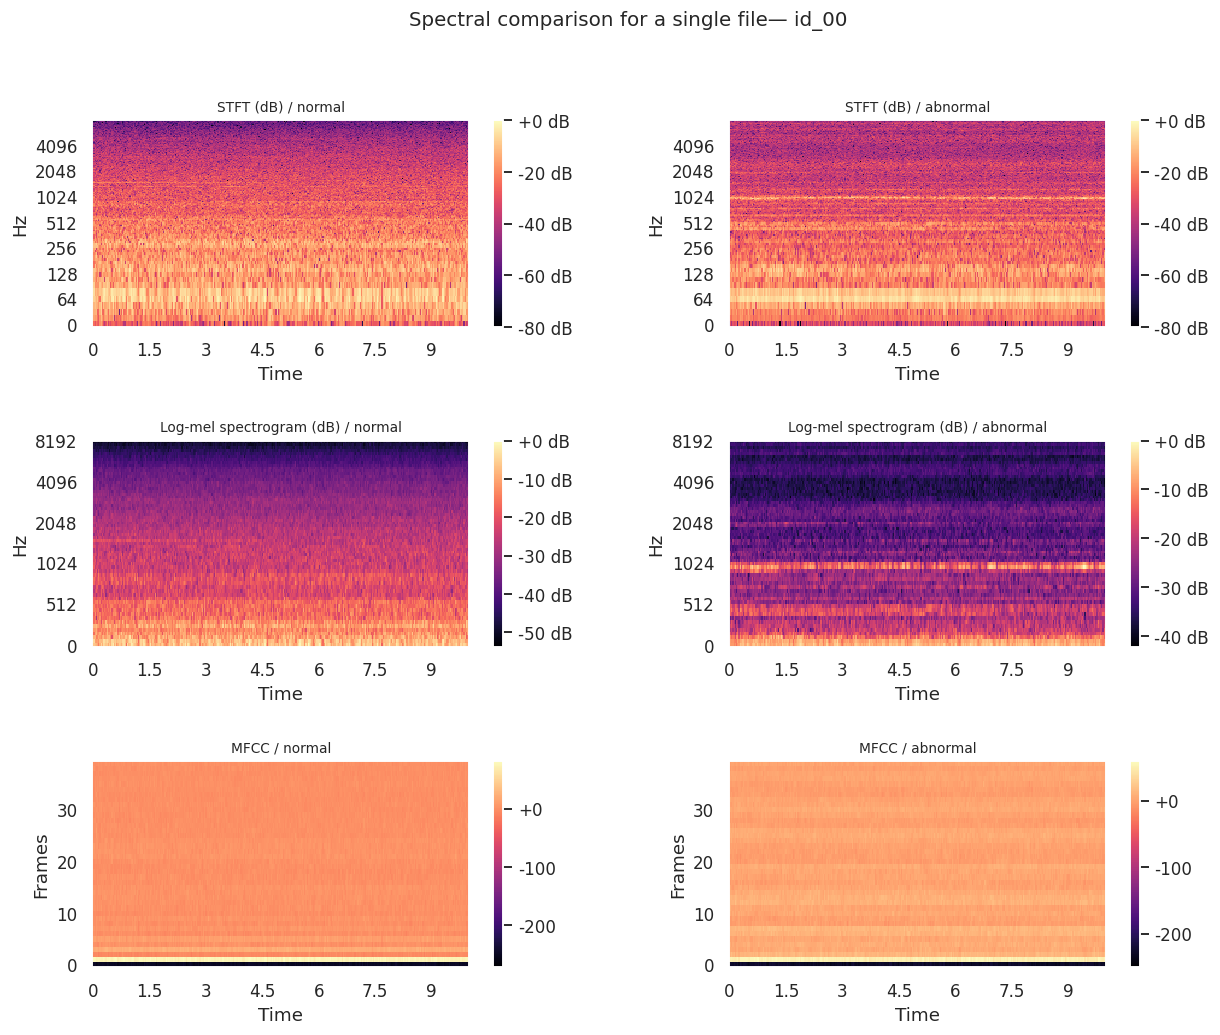

In [12]:
# ── plot STFT + log-mel + MFCC for id_00 normal vs abnormal ──────────────────
machine_id = 'id_00'
pairs = {}
for label in ('normal', 'abnormal'):
    path = manifest[(manifest['machine_id'] == machine_id) &
                    (manifest['label'] == label)]['path'].iloc[0]
    pairs[label] = load_mono(path)

fig = plt.figure(figsize=(13, 10))
fig.suptitle(f'Spectral comparison for a single file— {machine_id}', fontsize=13)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

rep_funcs = {
    'STFT (dB)': lambda y: librosa.amplitude_to_db(
                               np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN)), ref=np.max),
    'Log-mel spectrogram (dB)': compute_log_mel,
    'MFCC': compute_mfcc,
}

for row_idx, (rep_name, func) in enumerate(rep_funcs.items()):
    for col_idx, label in enumerate(('normal', 'abnormal')):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        M = func(pairs[label])
        img = librosa.display.specshow(
            M, sr=SR, hop_length=HOP_LEN,
            x_axis='time',
            y_axis='mel' if 'mel' in rep_name.lower() else
                    'log'  if 'STFT' in rep_name else
                    'frames',
            ax=ax, cmap='magma'
        )
        ax.set_title(f'{rep_name} / {label}', fontsize=9)
        plt.colorbar(img, ax=ax, format='%+2.0f dB' if 'MFCC' not in rep_name else '%+.0f')

plt.show()

### 5.1 — Per-frequency-band log-mel statistics

Rather than looking at a single clip, we aggregate across all training-split clips to get population-level spectral profiles:

- **Mean energy per mel bin** — the average spectral shape per group.  A shift here means the anomalous fan emits more or less power at specific frequency bands.
- **Temporal variability (std per bin)** — how much each frequency band fluctuates *within* a clip.  Higher std → that band is less stationary over the 10-second window.
- **Difference (abnormal − normal)** — which bands differ most.  Positive = louder in anomalous clips; negative = quieter.  These are the most discriminative frequencies for the downstream model.

Ribbons show ±1 std *across clips* (clip-to-clip variability), not within-clip variability.

normal:   0%|          | 0/3257 [00:00<?, ?it/s]

abnormal_ft:   0%|          | 0/293 [00:00<?, ?it/s]

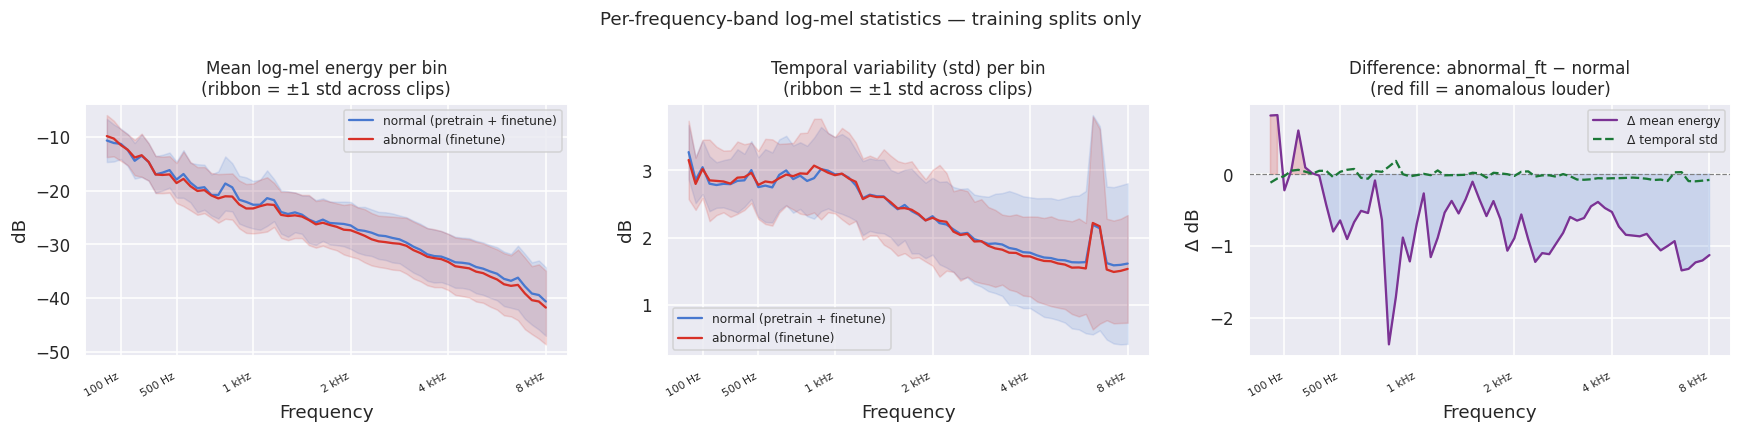

In [13]:
from tqdm.notebook import tqdm

# ── filter to training splits ─────────────────────────────────────────────────
groups = {
    'normal':      ['normal_pretrain', 'normal_finetune'],
    'abnormal_ft': ['abnormal_finetune'],
}

# For each clip compute per-mel-bin mean and std across T=313 time frames.
# log-mel shape per clip: (N_MELS=64, T)  →  clip_means/clip_stds: (N_clips, 64)
mel_stats = {}
for grp_name, splits in groups.items():
    mask  = manifest['split'].isin(splits)
    paths = manifest.loc[mask, 'path'].tolist()
    clip_means = np.zeros((len(paths), N_MELS), dtype=np.float32)
    clip_stds  = np.zeros((len(paths), N_MELS), dtype=np.float32)
    for i, path in enumerate(tqdm(paths, desc=grp_name, leave=False)):
        y = load_mono(path)
        S = compute_log_mel(y)          # (N_MELS, T)
        clip_means[i] = S.mean(axis=1)
        clip_stds[i]  = S.std(axis=1)
    mel_stats[grp_name] = dict(means=clip_means, stds=clip_stds)

# ── frequency labels for the mel-bin x-axis ───────────────────────────────────
mel_freqs   = librosa.mel_frequencies(n_mels=N_MELS, fmin=0.0, fmax=SR / 2)
freq_targets = [100, 500, 1000, 2000, 4000, 8000]
freq_bin_idx = [int(np.argmin(np.abs(mel_freqs - f))) for f in freq_targets]
freq_labels  = ['100 Hz', '500 Hz', '1 kHz', '2 kHz', '4 kHz', '8 kHz']

# ── plot ──────────────────────────────────────────────────────────────────────
colors = {'normal': '#4878cf', 'abnormal_ft': '#d73027'}
labels = {'normal': 'normal (pretrain + finetune)', 'abnormal_ft': 'abnormal (finetune)'}
x = np.arange(N_MELS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Per-frequency-band log-mel statistics — training splits only', fontsize=12)

# ── panel 1: mean energy ──────────────────────────────────────────────────────
ax = axes[0]
for grp, st in mel_stats.items():
    mu    = st['means'].mean(axis=0)
    sigma = st['means'].std(axis=0)
    ax.plot(x, mu, color=colors[grp], label=labels[grp], linewidth=1.5)
    ax.fill_between(x, mu - sigma, mu + sigma, alpha=0.15, color=colors[grp])
ax.set_title('Mean log-mel energy per bin\n(ribbon = ±1 std across clips)')
ax.set_xlabel('Frequency')
ax.set_ylabel('dB')
ax.set_xticks(freq_bin_idx)
ax.set_xticklabels(freq_labels, rotation=30, ha='right', fontsize=7)
ax.legend(fontsize=8)

# ── panel 2: temporal variability ─────────────────────────────────────────────
ax = axes[1]
for grp, st in mel_stats.items():
    mu    = st['stds'].mean(axis=0)
    sigma = st['stds'].std(axis=0)
    ax.plot(x, mu, color=colors[grp], label=labels[grp], linewidth=1.5)
    ax.fill_between(x, mu - sigma, mu + sigma, alpha=0.15, color=colors[grp])
ax.set_title('Temporal variability (std) per bin\n(ribbon = ±1 std across clips)')
ax.set_xlabel('Frequency')
ax.set_ylabel('dB')
ax.set_xticks(freq_bin_idx)
ax.set_xticklabels(freq_labels, rotation=30, ha='right', fontsize=7)
ax.legend(fontsize=8)

# ── panel 3: difference abnormal_ft − normal ──────────────────────────────────
ax = axes[2]
d_mean = mel_stats['abnormal_ft']['means'].mean(axis=0) - mel_stats['normal']['means'].mean(axis=0)
d_std  = mel_stats['abnormal_ft']['stds'].mean(axis=0)  - mel_stats['normal']['stds'].mean(axis=0)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.fill_between(x, d_mean, 0, where=d_mean > 0, alpha=0.2, color='#d73027')
ax.fill_between(x, d_mean, 0, where=d_mean < 0, alpha=0.2, color='#4878cf')
ax.plot(x, d_mean, color='#7b3294', label='Δ mean energy',   linewidth=1.5)
ax.plot(x, d_std,  color='#1b7837', label='Δ temporal std', linewidth=1.5, linestyle='--')
ax.set_title('Difference: abnormal_ft − normal\n(red fill = anomalous louder)')
ax.set_xlabel('Frequency')
ax.set_ylabel('Δ dB')
ax.set_xticks(freq_bin_idx)
ax.set_xticklabels(freq_labels, rotation=30, ha='right', fontsize=7)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

This shows clear differences around `1 kHz` frequency.

## 6 — Statistical summary of the feature space

Before training any model, it is worth understanding how separable the two classes are *in feature space*.  
We compute a summary statistics vector per clip (mean + std of each MFCC coefficient) — this is the standard compact descriptor used in classical pipelines.  
If the classes are already linearly separable with this descriptor, a simple classifier will do. If not, we need a more powerful representation.

In [ ]:
def extract_summary_features(path):
    """Returns a 1-D feature vector: [mean(MFCC), std(MFCC)] concatenated."""
    y = load_mono(path)
    mfcc = compute_mfcc(y)           # shape: (n_mfcc, T)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])

# Extract features from ALL files for visualisation,
# but track which split each file belongs to — downstream models must
# compute normalisation stats from normal_pretrain only.
print('Extracting summary MFCC features for all files...')
features = []
for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    features.append(extract_summary_features(row['path']))

X = np.array(features, dtype=np.float32)
y_labels = manifest['is_anomaly'].values
print(f'Feature matrix shape: {X.shape}')
print()

Extracting summary MFCC features for all files...


  0%|          | 0/5550 [00:00<?, ?it/s]

Feature matrix shape: (5550, 80)



### 6.1 — PCA visualization

PCA projects the high-dimensional feature vectors to 2D to let us see cluster structure.  
We colour by class and use marker shapes for machine ID.

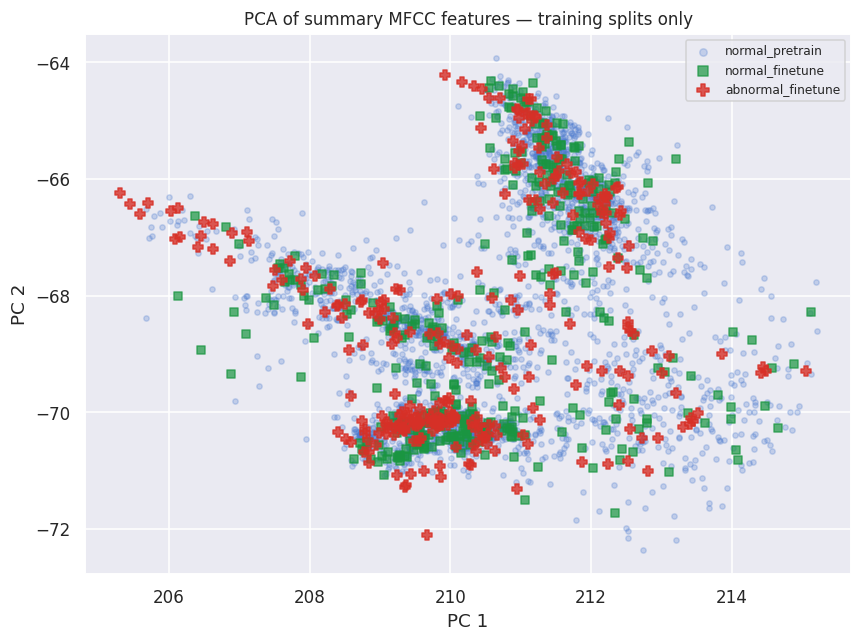

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Fit the scaler on normal_pretrain rows only — simulates real pipeline behaviour
pretrain_mask = manifest['split'] == 'normal_pretrain'
scaler = StandardScaler().fit(X[pretrain_mask])
X_scaled = scaler.transform(X)

X_pca = PCA(n_components=2, random_state=SEED).fit(X[pretrain_mask]).transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
split_styles = {
    'normal_pretrain':   ('#4878cf', 'o', 0.25, 12),
    'normal_finetune':   ('#1a9641', 's', 0.7,  25),
    'abnormal_finetune': ('#d73027', 'P', 0.8,  35),
}

for split, (color, marker, alpha, size) in split_styles.items():
    mask = manifest['split'] == split
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=marker, alpha=alpha, s=size, label=split)

ax.set_title('PCA of summary MFCC features — training splits only')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(fontsize=8, markerscale=1.4)
plt.tight_layout()
plt.show()
# The PCA and scaler are fitted on normal_pretrain only (blue cloud).
# If normal_finetune points fall within the pretrain cloud, the split is well-balanced.
# Separation between the normal clouds and abnormal_finetune points indicates
# that MFCC features carry discriminative signal before any model training.

A linear classifier won't be enough, we will need more advanced techniques

### 6.2 — Distribution of individual MFCC coefficients

Violin plots show whether the normal and abnormal distributions differ *coefficient by coefficient*.  
Coefficients where the distributions overlap heavily will not contribute useful signal.

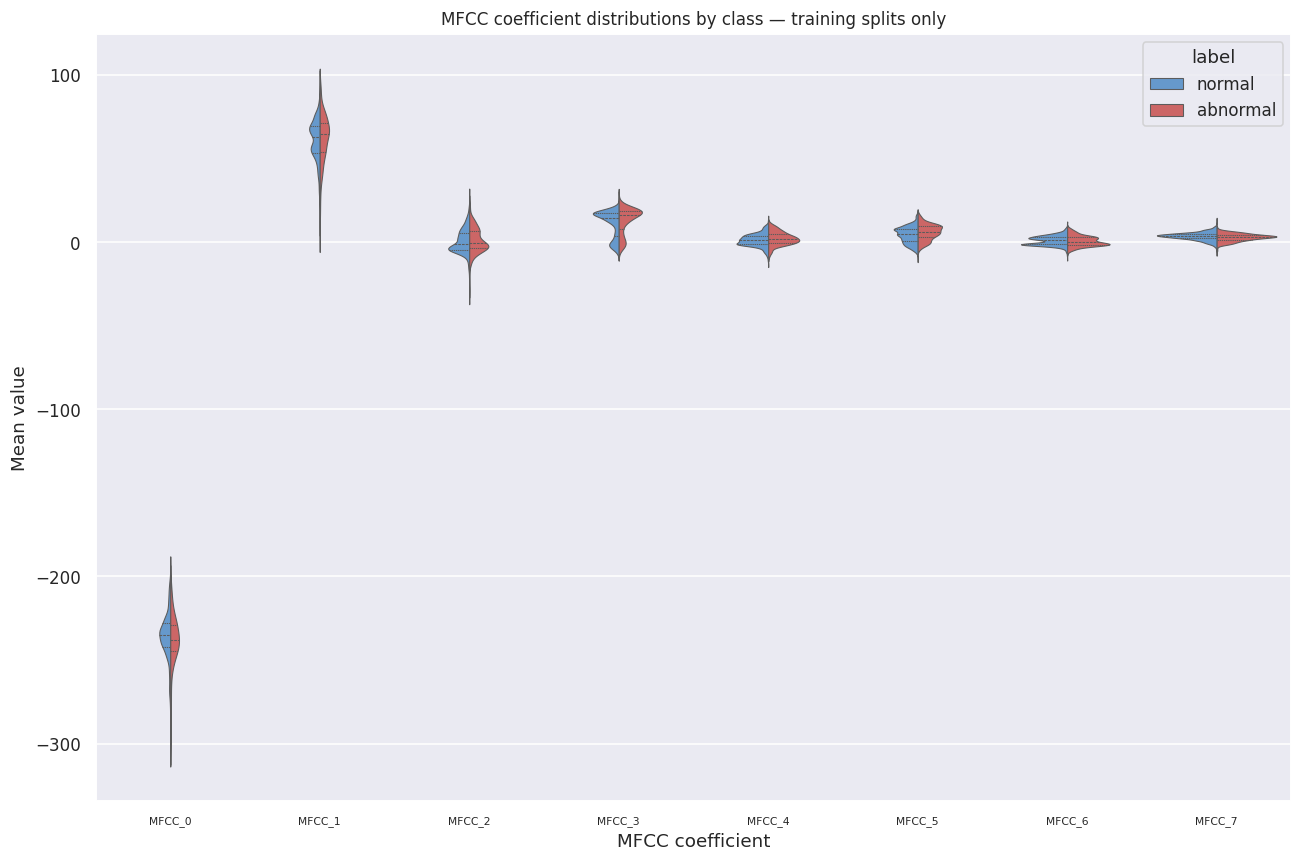

In [22]:
# Use mean of MFCC coefficients (first half of feature vector)
n_mfcc = 8
train_splits = ['normal_pretrain', 'normal_finetune', 'abnormal_finetune']
train_mask = manifest['split'].isin(train_splits)

df_mfcc = pd.DataFrame(
    X[train_mask, :n_mfcc],
    columns=[f'MFCC_{i}' for i in range(n_mfcc)]
)
df_mfcc['label'] = manifest.loc[train_mask, 'label'].values

df_long = df_mfcc.melt(id_vars='label', var_name='coefficient', value_name='mean')

fig, ax = plt.subplots(figsize=(12, 8))
sns.violinplot(
    data=df_long, x='coefficient', y='mean', hue='label',
    split=True, inner='quartile', palette={'normal': '#5599dd', 'abnormal': '#dd5555'},
    ax=ax, linewidth=0.7
)
ax.set_title('MFCC coefficient distributions by class — training splits only')
ax.set_xlabel('MFCC coefficient')
ax.set_ylabel('Mean value')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

In [23]:
from scipy import stats

# ── build group masks ─────────────────────────────────────────────────────────
normal_mask   = manifest['split'].isin(['normal_pretrain', 'normal_finetune'])
abnormal_mask = manifest['split'] == 'abnormal_finetune'

X_normal   = X_scaled[normal_mask]
X_abnormal = X_scaled[abnormal_mask]

feat_names = (
    [f'MFCC{i}_mean' for i in range(N_MFCC)] +
    [f'MFCC{i}_std'  for i in range(N_MFCC)]
)

# ── per-feature statistics ────────────────────────────────────────────────────
rows = []
for j, name in enumerate(feat_names):
    n, a = X_normal[:, j], X_abnormal[:, j]
    pooled_std = np.sqrt((n.std()**2 + a.std()**2) / 2)
    cohen_d = (n.mean() - a.mean()) / pooled_std if pooled_std > 0 else 0.0
    t_stat, p_val = stats.ttest_ind(n, a, equal_var=False)
    rows.append({
        'feature':        name,
        'normal_mean':    n.mean(),
        'normal_std':     n.std(),
        'abnormal_mean':  a.mean(),
        'abnormal_std':   a.std(),
        'mean_diff':      n.mean() - a.mean(),
        'cohen_d':        cohen_d,
        'abs_cohen_d':    abs(cohen_d),
        't_stat':         t_stat,
        'p_value':        p_val,
    })

feat_stats = pd.DataFrame(rows).sort_values('abs_cohen_d', ascending=False)

# ── group-level summary ───────────────────────────────────────────────────────
print('Group sizes')
print(f'  normal (pretrain + finetune) : {X_normal.shape[0]:,} files')
print(f'  abnormal_finetune            : {X_abnormal.shape[0]:,} files')
print()
print('Per-group mean feature norm (L2) — rough measure of how far each group sits from the pretrain centroid')
print(f'  normal   : {np.linalg.norm(X_normal,   axis=1).mean():.3f}  ± {np.linalg.norm(X_normal,   axis=1).std():.3f}')
print(f'  abnormal : {np.linalg.norm(X_abnormal, axis=1).mean():.3f}  ± {np.linalg.norm(X_abnormal, axis=1).std():.3f}')
print()

# ── top discriminating features ───────────────────────────────────────────────
print('Top 10 features by |Cohen\'s d|  (effect size: <0.2 small, 0.5 medium, 0.8 large)')
display(
    feat_stats.head(10)[['feature', 'normal_mean', 'normal_std',
                          'abnormal_mean', 'abnormal_std',
                          'mean_diff', 'cohen_d', 'p_value']]
    .style
    .format({
        'normal_mean':   '{:+.3f}', 'normal_std':   '{:.3f}',
        'abnormal_mean': '{:+.3f}', 'abnormal_std': '{:.3f}',
        'mean_diff':     '{:+.3f}', 'cohen_d':      '{:+.3f}',
        'p_value':       '{:.2e}',
    })
    .background_gradient(subset='cohen_d', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    .set_caption('Features sorted by |Cohen\'s d| — normal_pretrain+finetune vs abnormal_finetune')
)

# ── significance summary ──────────────────────────────────────────────────────
sig = feat_stats[feat_stats['p_value'] < 0.05]
large = feat_stats[feat_stats['abs_cohen_d'] >= 0.8]
print(f'\n{len(sig)}/{len(feat_stats)} features are significant at p < 0.05 (Welch t-test, uncorrected)')
print(f'{len(large)}/{len(feat_stats)} features have |Cohen\'s d| ≥ 0.8 (large effect)')


Group sizes
  normal (pretrain + finetune) : 3,257 files
  abnormal_finetune            : 293 files

Per-group mean feature norm (L2) — rough measure of how far each group sits from the pretrain centroid
  normal   : 8.321  ± 3.343
  abnormal : 8.367  ± 3.351

Top 10 features by |Cohen's d|  (effect size: <0.2 small, 0.5 medium, 0.8 large)


,feature,normal_mean,normal_std,abnormal_mean,abnormal_std,mean_diff,cohen_d,p_value
37,MFCC37_mean,-0.005,1.004,-0.459,0.957,+0.453,+0.462,1.20e-13
24,MFCC24_mean,+0.004,0.997,+0.360,0.928,-0.356,-0.369,1.28e-09
18,MFCC18_mean,-0.003,1.001,+0.343,0.877,-0.346,-0.367,5.61e-10
5,MFCC5_mean,-0.004,0.995,+0.328,0.930,-0.332,-0.345,1.42e-08
7,MFCC7_mean,+0.003,0.998,-0.279,0.925,+0.282,+0.293,1.15e-06
36,MFCC36_mean,-0.001,0.994,-0.279,0.926,+0.278,+0.289,1.64e-06
4,MFCC4_mean,+0.002,1.000,+0.265,1.031,-0.263,-0.259,3.62e-05
39,MFCC39_mean,+0.006,1.006,+0.243,0.847,-0.237,-0.255,8.76e-06
17,MFCC17_mean,+0.003,1.003,+0.247,1.001,-0.244,-0.244,7.92e-05
8,MFCC8_mean,+0.001,1.002,+0.250,1.048,-0.249,-0.242,1.18e-04



27/80 features are significant at p < 0.05 (Welch t-test, uncorrected)
0/80 features have |Cohen's d| ≥ 0.8 (large effect)


In case we need to cut down the amount of features used in our model, we can use Cohen's d effect size to determine which ones to use.

## 7 — Inter-machine-ID variability

MIMII contains four distinct fan units (id_00, id_02, id_04, id_06).  
They are **different physical machines** with potentially different operating points.  
This has a critical implication: **models must be trained and evaluated per machine ID**, not across all IDs, because a cross-ID model may just learn machine identity instead of normalcy.

Here we quantify how spread-out normal sounds are across IDs.

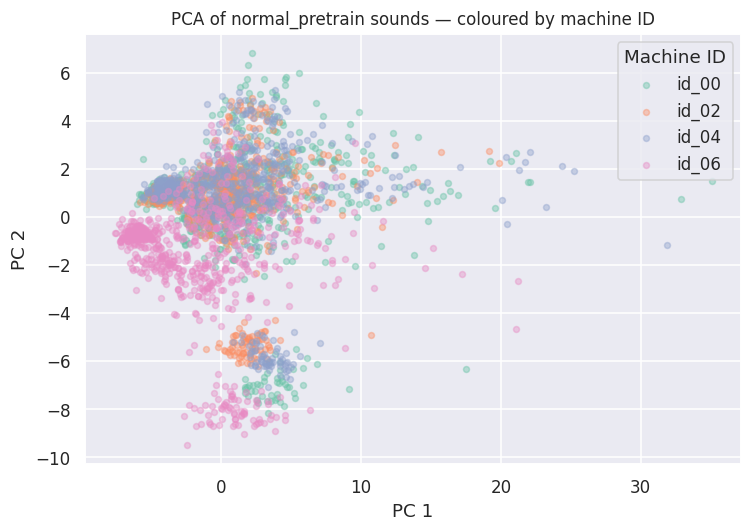

In [24]:
# Use normal_pretrain only — the same data the SSL feature extractor will see
pretrain_mask = manifest['split'] == 'normal_pretrain'
X_pretrain  = X_scaled[pretrain_mask]
ids_pretrain = manifest['machine_id'].values[pretrain_mask]

X_pca_n = PCA(n_components=2, random_state=SEED).fit_transform(X_pretrain)

fig, ax = plt.subplots(figsize=(7, 5))
palette = sns.color_palette('Set2', 4)
for i, mid in enumerate(MACHINE_IDS):
    mask = ids_pretrain == mid
    ax.scatter(X_pca_n[mask, 0], X_pca_n[mask, 1],
               c=[palette[i]], alpha=0.4, s=15, label=mid)

ax.set_title('PCA of normal_pretrain sounds — coloured by machine ID')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(title='Machine ID')
plt.tight_layout()
plt.show()

If the clusters are well-separated, separate per-ID models are mandatory.  
If they overlap strongly, a shared feature extractor with ID-specific heads may work.

In our case, there are clear differences between `id_06` and the rest of the machines. This suggest our final model should be trained by `machine_id`. We can do this during self-supervised pre-training step or at the fine-tune step and compare our findings.

## 8 — Energy & duration sanity checks

Check that all clips have consistent length and no silent/clipped recordings.

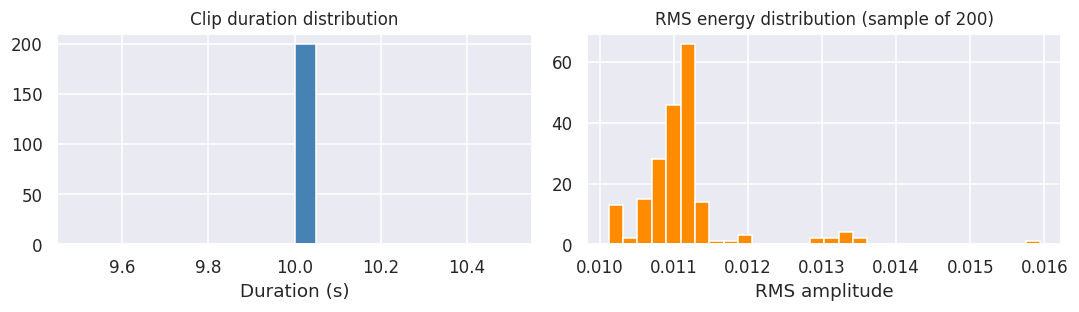

Duration: min=10.00s  max=10.00s
RMS    : min=0.0101  max=0.0159  (near-silence threshold < 0.001 would flag issues)


In [17]:
# Sample 200 files for a quick check (full scan would take a few minutes)
sample = manifest.sample(200, random_state=SEED)

durations, rms_vals = [], []
for _, row in sample.iterrows():
    y = load_mono(row['path'])
    durations.append(len(y) / SR)
    rms_vals.append(float(np.sqrt(np.mean(y**2))))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(durations, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Clip duration distribution')
axes[0].set_xlabel('Duration (s)')

axes[1].hist(rms_vals, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('RMS energy distribution (sample of 200)')
axes[1].set_xlabel('RMS amplitude')

plt.tight_layout()
plt.show()

print(f"Duration: min={min(durations):.2f}s  max={max(durations):.2f}s")
print(f"RMS    : min={min(rms_vals):.4f}  max={max(rms_vals):.4f}  "
      f"(near-silence threshold < 0.001 would flag issues)")

## 9 — Log-mel spectrogram batch preview

A grid of spectrograms gives a qualitative feel for intra-class variability.  
If normal sounds look highly consistent, an autoencoder will train easily.  
High variability within the normal class makes the task harder.

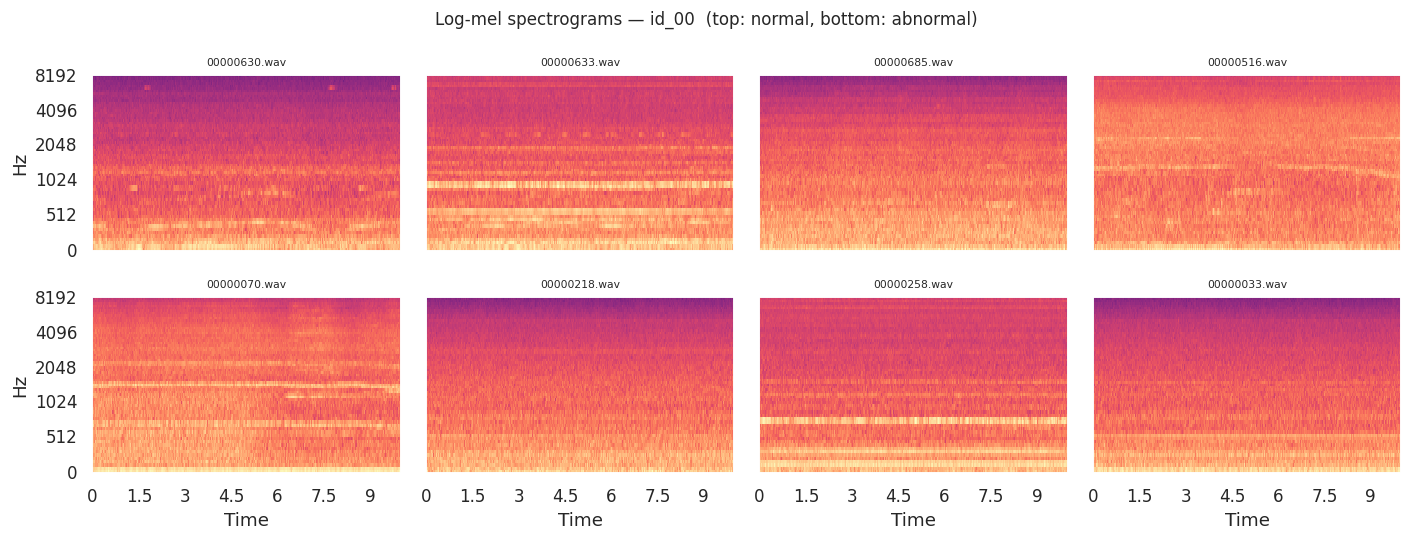

In [25]:
machine_id = 'id_00'
n_cols = 4

fig, axes = plt.subplots(2, n_cols, figsize=(13, 5))
fig.suptitle(f'Log-mel spectrograms — {machine_id}  (top: normal, bottom: abnormal)', fontsize=11)

for row_idx, label in enumerate(('normal', 'abnormal')):
    paths = manifest[(manifest['machine_id'] == machine_id) &
                     (manifest['label'] == label)]['path'].sample(n_cols, random_state=SEED).tolist()
    for col_idx, path in enumerate(paths):
        ax = axes[row_idx, col_idx]
        y = load_mono(path)
        S_db = compute_log_mel(y)
        librosa.display.specshow(S_db, sr=SR, hop_length=HOP_LEN,
                                  x_axis='time', y_axis='mel', ax=ax,
                                  cmap='magma', vmin=-80, vmax=0)
        ax.set_title(path.name, fontsize=7)
        ax.label_outer()

plt.tight_layout()
plt.show()

## 10 — EDA Summary & Next Steps

### Key findings
| Finding | Implication |
|---|---|
| ~3:1 normal/abnormal ratio | Use AUC-ROC, not accuracy; do NOT oversample abnormal for training |
| 8-channel recordings | Mix to mono or pick channel 0; revisit with beamforming if baseline is weak |
| All clips 10 s / 16 kHz | No variable-length handling needed; fixed-size tensors throughout |
| MFCC separability (PCA) | There are visible differences between machine IDs but no clear differences between normal and abnormal |
| 4 distinct machine IDs | Fine-tune/evaluate **per ID** to avoid learning machine identity, we can experiment doing the pre-training with all machine IDs |
